In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print("Class dist (train):", dict(zip(*np.unique(y_train, return_counts=True))))

Train: (87554, 187, 1)
Test:  (21892, 187, 1)
Class dist (train): {np.int32(0): np.int64(72471), np.int32(1): np.int64(2223), np.int32(2): np.int64(5788), np.int32(3): np.int64(641), np.int32(4): np.int64(6431)}


In [4]:
X_flat = X_train.reshape(len(X_train), -1)

smote = SMOTE(
    sampling_strategy={
        1: 5000,   # S: 2223 → 5000 (less aggressive than before)
        3: 2500,   # F:  641 → 2500 (less aggressive than before)
    },
    random_state=42,
    k_neighbors=5
)

X_res, y_res = smote.fit_resample(X_flat, y_train)
X_res = X_res.reshape(-1, 187, 1).astype(np.float32)

print("After SMOTE:", dict(zip(*np.unique(y_res, return_counts=True))))

After SMOTE: {np.int32(0): np.int64(72471), np.int32(1): np.int64(5000), np.int32(2): np.int64(5788), np.int32(3): np.int64(2500), np.int32(4): np.int64(6431)}


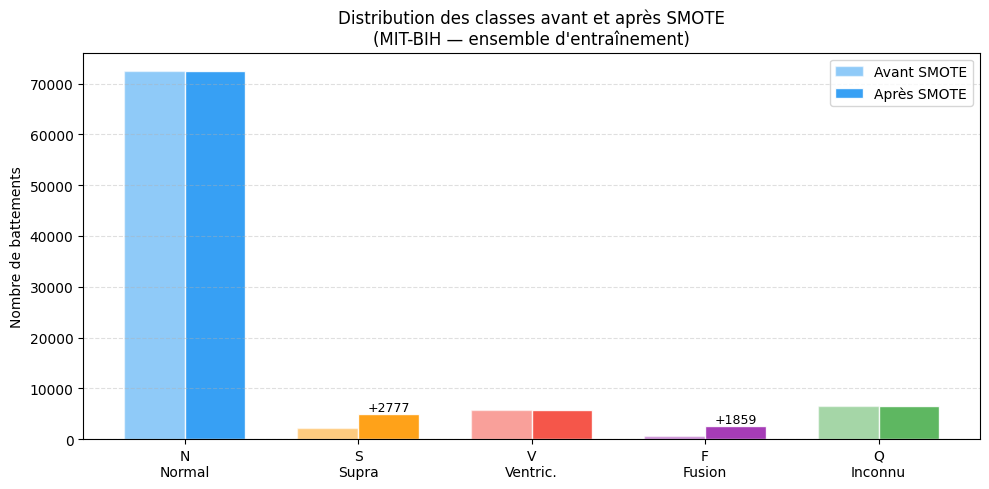

In [5]:


before = {0: 72471, 1: 2223, 2: 5788, 3: 641, 4: 6431}
after  = {0: 72471, 1: 5000, 2: 5788, 3: 2500, 4: 6431}
labels = ['N\nNormal','S\nSupra','V\nVentric.','F\nFusion','Q\nInconnu']
colors = ['#2196F3','#FF9800','#F44336','#9C27B0','#4CAF50']

x = np.arange(5)
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, before.values(), width,
               label='Avant SMOTE', color=colors, alpha=0.5, edgecolor='white')
bars2 = ax.bar(x + width/2, after.values(), width,
               label='Après SMOTE', color=colors, alpha=0.9, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Nombre de battements')
ax.set_title('Distribution des classes avant et après SMOTE\n(MIT-BIH — ensemble d\'entraînement)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Annotations sur les barres S et F seulement
for i, (b, a) in enumerate(zip(before.values(), after.values())):
    if i in [1, 3]:
        ax.annotate(f'+{a-b}', xy=(x[i]+width/2, a),
                     ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('figures/smote_distribution.png', dpi=150)
plt.show()

In [4]:
classes = np.unique(y_res)
weights = compute_class_weight('balanced', classes=classes, y=y_res)
cw = dict(zip(classes.tolist(), weights.tolist()))
print("Class weights:", {k: round(v, 3) for k, v in cw.items()})

Class weights: {0: 0.254, 1: 3.688, 2: 3.186, 3: 7.375, 4: 2.867}


In [5]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=5)
        probs = tf.reduce_sum(y_pred * y_true_oh, axis=-1)
        focal_weight = alpha * tf.pow(1.0 - probs, gamma)
        loss = -focal_weight * tf.math.log(probs + 1e-8)
        return tf.reduce_mean(loss)
    return loss_fn

In [6]:
def build_model(input_shape=(187, 1), num_classes=5):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv1D(32, 5, padding='same', activation='relu')(inputs)
    x = keras.layers.Conv1D(32, 5, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling1D(2)(x)
    x = keras.layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = keras.layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling1D(2)(x)
    x = keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0),
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 187, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 93, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 93, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,189 (223.39 KB)

 Trainable params: 57,189 (223.39 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
os.makedirs('models', exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(
        patience=7,                     # balanced — not too early, not frozen
        restore_best_weights=True,
        monitor='val_loss'
    ),
    keras.callbacks.ModelCheckpoint(
        'models/cnn1d_final.keras',     # use .keras format (no warning)
        save_best_only=True,
        monitor='val_loss'
    ),
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=4,
        monitor='val_loss',
        min_lr=1e-5,                    # ← KEY FIX: LR never goes below 1e-5
        verbose=1
    )
]
print("Callbacks ready. min_lr floor = 1e-5")

Callbacks ready. min_lr floor = 1e-5


In [8]:
history = model.fit(
    X_res, y_res,
    epochs=60,
    batch_size=256,
    validation_data=(X_test, y_test),
    class_weight=cw,
    callbacks=callbacks,
    verbose=1
)
np.save('models/history_final.npy', history.history)
print("Training done.")

Epoch 1/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8076 - loss: 0.0922 - val_accuracy: 0.8964 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 2/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.8607 - loss: 0.0471 - val_accuracy: 0.9134 - val_loss: 0.0336 - learning_rate: 0.0010
Epoch 3/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.8834 - loss: 0.0384 - val_accuracy: 0.9207 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 4/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.8942 - loss: 0.0346 - val_accuracy: 0.9327 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 5/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9040 - loss: 0.0307 - val_accuracy: 0.9414 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 6/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.9092 - loss: 0.0282 - val_accuracy: 0.9385 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 7/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9223 - l

In [9]:
y_proba = model.predict(X_test, batch_size=256)
y_pred_raw = np.argmax(y_proba, axis=1)

class_names = ['N Normal', 'S Supra', 'V Ventricular', 'F Fusion', 'Q Unknown']
print("=== RAW (no threshold adjustment) ===")
print(classification_report(y_test, y_pred_raw, target_names=class_names))

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
=== RAW (no threshold adjustment) ===
               precision    recall  f1-score   support

     N Normal       0.98      0.99      0.99     18118
      S Supra       0.76      0.63      0.69       556
V Ventricular       0.95      0.93      0.94      1448
     F Fusion       0.75      0.78      0.77       162
    Q Unknown       0.99      0.98      0.98      1608

     accuracy                           0.97     21892
    macro avg       0.89      0.86      0.87     21892
 weighted avg       0.97      0.97      0.97     21892



In [10]:
# Boosting = multiply by value > 1.0
# This raises the effective probability of S and F, making model more willing to predict them
print("Scanning S boost (multiply P(S) upward):\n")
results = []
for s_boost in [1.0, 1.3, 1.5, 1.8, 2.0, 2.5, 3.0]:
    for f_boost in [1.0, 1.3, 1.5, 1.8]:
        thresholds = np.array([1.0, s_boost, 1.0, f_boost, 1.0])
        y_pred = np.argmax(y_proba * thresholds, axis=1)
        s_f1 = f1_score(y_test, y_pred, average=None)[1]
        f_f1 = f1_score(y_test, y_pred, average=None)[3]
        mac  = f1_score(y_test, y_pred, average='macro')
        results.append((s_boost, f_boost, s_f1, f_f1, mac))
        print(f"  S={s_boost:.1f} F={f_boost:.1f} → S_F1={s_f1:.3f}  F_F1={f_f1:.3f}  macro={mac:.3f}")

Scanning S boost (multiply P(S) upward):

  S=1.0 F=1.0 → S_F1=0.688  F_F1=0.766  macro=0.873
  S=1.0 F=1.3 → S_F1=0.688  F_F1=0.743  macro=0.868
  S=1.0 F=1.5 → S_F1=0.688  F_F1=0.718  macro=0.863
  S=1.0 F=1.8 → S_F1=0.688  F_F1=0.693  macro=0.858
  S=1.3 F=1.0 → S_F1=0.679  F_F1=0.766  macro=0.871
  S=1.3 F=1.3 → S_F1=0.679  F_F1=0.743  macro=0.866
  S=1.3 F=1.5 → S_F1=0.679  F_F1=0.718  macro=0.861
  S=1.3 F=1.8 → S_F1=0.679  F_F1=0.695  macro=0.856
  S=1.5 F=1.0 → S_F1=0.675  F_F1=0.766  macro=0.870
  S=1.5 F=1.3 → S_F1=0.675  F_F1=0.743  macro=0.865
  S=1.5 F=1.5 → S_F1=0.675  F_F1=0.718  macro=0.860
  S=1.5 F=1.8 → S_F1=0.675  F_F1=0.695  macro=0.855
  S=1.8 F=1.0 → S_F1=0.632  F_F1=0.766  macro=0.860
  S=1.8 F=1.3 → S_F1=0.632  F_F1=0.743  macro=0.856
  S=1.8 F=1.5 → S_F1=0.632  F_F1=0.718  macro=0.851
  S=1.8 F=1.8 → S_F1=0.632  F_F1=0.695  macro=0.846
  S=2.0 F=1.0 → S_F1=0.609  F_F1=0.766  macro=0.855
  S=2.0 F=1.3 → S_F1=0.609  F_F1=0.743  macro=0.851
  S=2.0 F=1.5 → S_F1=0

In [11]:
# From the scan above, find the row with highest macro F1
best = max(results, key=lambda x: x[4])
s_boost, f_boost, s_f1, f_f1, mac = best
print(f"\nBest config: S_boost={s_boost}, F_boost={f_boost}")
print(f"  S F1={s_f1:.3f}, F F1={f_f1:.3f}, macro={mac:.3f}\n")

thresholds = np.array([1.0, s_boost, 1.0, f_boost, 1.0])
y_pred_final = np.argmax(y_proba * thresholds, axis=1)

print("=== FINAL RESULT ===")
print(classification_report(y_test, y_pred_final, target_names=class_names))

np.save('models/y_pred_final.npy', y_pred_final)
np.save('models/y_proba_final.npy', y_proba)


Best config: S_boost=1.0, F_boost=1.0
  S F1=0.688, F F1=0.766, macro=0.873

=== FINAL RESULT ===
               precision    recall  f1-score   support

     N Normal       0.98      0.99      0.99     18118
      S Supra       0.76      0.63      0.69       556
V Ventricular       0.95      0.93      0.94      1448
     F Fusion       0.75      0.78      0.77       162
    Q Unknown       0.99      0.98      0.98      1608

     accuracy                           0.97     21892
    macro avg       0.89      0.86      0.87     21892
 weighted avg       0.97      0.97      0.97     21892



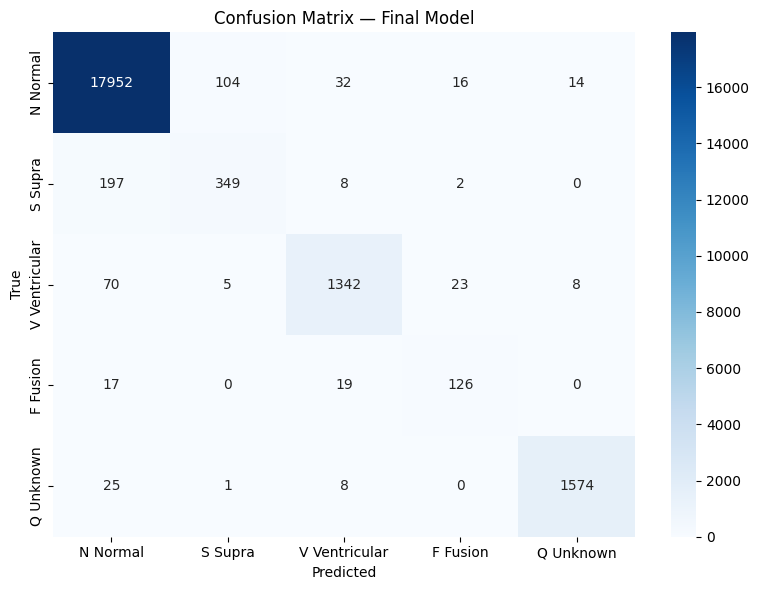

In [12]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Final Model')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('models/confusion_matrix_final.png', dpi=150)
plt.show()

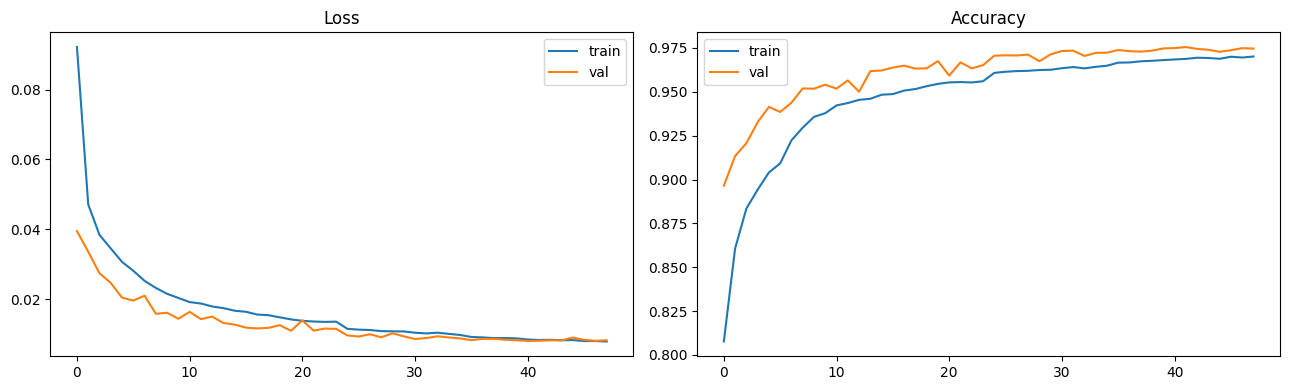

LR range: 6.25000029685907e-05 → 0.0010000000474974513


: 

In [ ]:
history = np.load('models/history_final.npy', allow_pickle=True).item()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,4))
ax1.plot(history['loss'], label='train'); ax1.plot(history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history['accuracy'], label='train'); ax2.plot(history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig('models/training_curves_final.png', dpi=150)
plt.show()

# Print the LR history to confirm it stopped at 1e-5
print("LR range:", min(history['learning_rate']), "→", max(history['learning_rate']))